In [46]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(123)
m = 2000

experiences = rng.exponential(scale=4, size=(m, 1))
education = rng.normal(7, 4, size=(m, 1))

# salaries = rng.gamma(shape=35, scale=2, size=(m, 1))
salaries = 20 + 7 * experiences + 5 * education + rng.normal(0, 5, size=(m, 1))

In [47]:
from sklearn.preprocessing import add_dummy_feature

X = np.hstack([experiences / 10, education / 10])
X_dummy = add_dummy_feature(X)

y = salaries / 100

X_dummy, y

(array([[1.        , 0.238789  , 0.66774206],
        [1.        , 0.04681242, 1.0110066 ],
        [1.        , 0.10071788, 0.93592318],
        ...,
        [1.        , 1.63372722, 0.71608266],
        [1.        , 0.03350721, 0.86319078],
        [1.        , 0.28983801, 0.83907169]], shape=(2000, 3)),
 array([[0.60266247],
        [0.67985736],
        [0.74634547],
        ...,
        [1.69464557],
        [0.59789934],
        [0.86632611]], shape=(2000, 1)))

In [48]:
eta = 0.1
n_epochs = 30000
m = len(X_dummy)

rng = np.random.default_rng(123)
theta = rng.standard_normal((3, 1))

for epoch in range(n_epochs):
    gradients = 1 / m * X_dummy.T @ (X_dummy @ theta - y)
    theta = theta - eta * gradients

theta

array([[0.20024703],
       [0.70194851],
       [0.49979567]])

In [50]:
X_test_batch = np.array([
    [1., 0.1, 0.2]
])

X_test_batch @ theta

array([[0.37040102]])

Learned theta (scaled):
  θ₀ bias:       2.0092  (true scaled: 2.0000)
  θ₁ experience: 2.9309  (true scaled: 0.3000)
  θ₂ education:  5.0315  (true scaled: 0.5000)


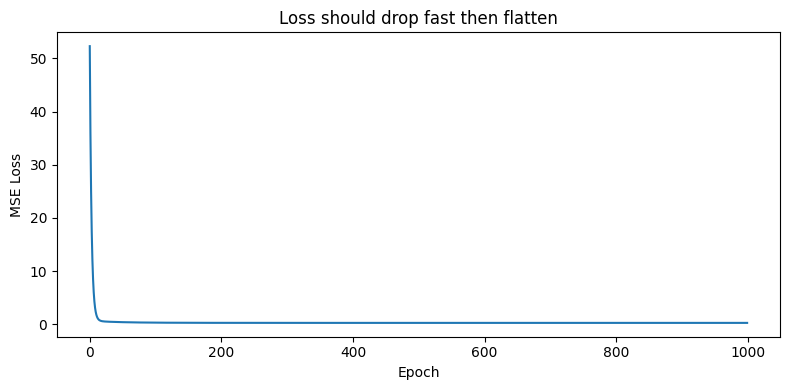


Predicted salary (8yr exp, 10yr edu): $93.9k
Expected from true formula: $94.0k


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── 1. DATA GENERATION ──────────────────────────────────────────
rng = np.random.default_rng(123)
m = 2000

experiences = np.round(np.clip(experiences, 0, 40))
education   = np.round(np.clip(education, 0, 20))

# experiences = rng.exponential(scale=4, size=(m, 1))   # 0–20 yrs
# education   = rng.normal(7, 4, size=(m, 1))            # 0–15 yrs, clipped below

# TRUE relationship — gradient descent should recover these weights
TRUE_BIAS   =  20.0
TRUE_W_EXP  =   3.0
TRUE_W_EDU  =   5.0

salaries = (TRUE_BIAS
            + TRUE_W_EXP * experiences
            + TRUE_W_EDU * education
            + rng.normal(0, 5, size=(m, 1)))           # real-world noise

# ── 2. PREPROCESSING ────────────────────────────────────────────
from sklearn.preprocessing import add_dummy_feature

X = np.hstack([experiences / 10, education / 10])
X_b = add_dummy_feature(X)                            
y = salaries / 10                                      

# ── 3. GRADIENT DESCENT ─────────────────────────────────────────
eta  = 0.1
n_epochs = 1000                                       
m = len(X_b)

rng   = np.random.default_rng(123)
theta = rng.standard_normal((3, 1))

loss_history = []

for epoch in range(n_epochs):
    predictions = X_b @ theta
    errors = predictions - y
    gradients = 1 / m * X_b.T @ errors
    theta = theta - eta * gradients

    # mean squared error — track to confirm loss is going down
    mse = float(np.mean(errors ** 2))
    loss_history.append(mse)

# ── 4. RESULTS ──────────────────────────────────────────────────
print("Learned theta (scaled):")
print(f"θ₀ bias: {theta[0,0]:.4f}  (true scaled: {TRUE_BIAS  /10:.4f})")
print(f"θ₁ experience: {theta[1,0]:.4f}  (true scaled: {TRUE_W_EXP/10:.4f})")
print(f"θ₂ education: {theta[2,0]:.4f}  (true scaled: {TRUE_W_EDU/10:.4f})")

# ── 5. LOSS CURVE ───────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss should drop fast then flatten")
plt.tight_layout()
plt.show()

# ── 6. PREDICTION ───────────────────────────────────────────────
# predict salary for: 8 yrs experience, 10 yrs education
X_test = add_dummy_feature(np.array([[8/10, 10/10]]))
pred_scaled = X_test @ theta
pred_salary = pred_scaled * 10                         # undo the /10 scaling

print(f"\nPredicted salary (8yr exp, 10yr edu): ${pred_salary[0,0]:.1f}k")
print(f"Expected from true formula: ${TRUE_BIAS + TRUE_W_EXP*8 + TRUE_W_EDU*10:.1f}k")